# 05 — Community Detection & Network Evolution
## Portuguese Public Procurement Network

**Research Question:** Which companies have a dominant position within specific municipalities?

**This notebook covers:**
1. Community Detection (Louvain algorithm)
2. Community Analysis & Interpretation
3. Network Evolution (2023–2026)
4. Key Insights & Discussion (The 4 Golden Questions)

## 1. Setup & Network Reconstruction

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from community import community_louvain  # pip install python-louvain
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load data
data = pd.read_csv('../data/preprocessed_data.csv')
date_cols = ['dataDecisaoAdjudicacao', 'dataCelebracaoContrato', 'dataPublicacao', 'dataFechoContrato']
for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

print(f"Loaded {len(data):,} contracts")
print(f"Date range: {data['dataCelebracaoContrato'].min()} → {data['dataCelebracaoContrato'].max()}")

Loaded 690 contracts
Date range: 2025-01-01 00:00:00 → 2026-02-09 00:00:00


In [3]:
def build_network(df):
    """Build directed weighted network from preprocessed contract data."""
    G = nx.DiGraph()

    edge_data = df.groupby(['adjudicante_clean', 'adjudicatarios_clean']).agg(
        total_value=('precoContratual', 'sum'),
        num_contracts=('idcontrato', 'count'),
        avg_value=('precoContratual', 'mean'),
        cities=('city', lambda x: list(x.unique())),
        cpv_categories=('agg_cpv', lambda x: list(x.unique())),
        first_contract=('dataCelebracaoContrato', 'min'),
        last_contract=('dataCelebracaoContrato', 'max')
    ).reset_index()

    all_adj = set(df['adjudicante_clean'].unique())
    all_awd = set(df['adjudicatarios_clean'].unique())
    both = all_adj & all_awd

    for node in all_adj - both:
        G.add_node(node, node_type='adjudicante')
    for node in all_awd - both:
        G.add_node(node, node_type='adjudicatario')
    for node in both:
        G.add_node(node, node_type='both')

    for _, row in edge_data.iterrows():
        G.add_edge(row['adjudicante_clean'], row['adjudicatarios_clean'],
                   weight=row['total_value'], num_contracts=row['num_contracts'],
                   avg_value=row['avg_value'], cities=row['cities'],
                   cpv_categories=row['cpv_categories'])
    return G

# Build full network
G = build_network(data)
print(f"Network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Network: 564 nodes, 566 edges


## 2. Community Detection

We use the **Louvain** algorithm to identify communities (clusters) in the network.
- Communities may reveal geographic groupings, sector-based clusters, or preferential relationships.
- **Modularity** measures how well the network separates into communities (vs. random).

In [4]:
# Community detection requires undirected graph
G_undirected = G.to_undirected()

# Louvain community detection (weighted)
print("Running Louvain community detection...")
partition = community_louvain.best_partition(G_undirected, weight='weight', resolution=1.0, random_state=42)

# Modularity score
modularity = community_louvain.modularity(partition, G_undirected, weight='weight')

# Community statistics
community_sizes = Counter(partition.values())
n_communities = len(community_sizes)
sorted_communities = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*60}")
print(f"COMMUNITY DETECTION RESULTS (Louvain)")
print(f"{'='*60}")
print(f"Number of communities: {n_communities}")
print(f"Modularity score: {modularity:.4f}")
print(f"\nTop 10 communities by size:")
print(f"{'Community':<12} {'Nodes':<10} {'% of Network':<15}")
print("-"*37)
for comm_id, size in sorted_communities[:10]:
    print(f"{comm_id:<12} {size:<10} {size/G.number_of_nodes()*100:.1f}%")

Running Louvain community detection...

COMMUNITY DETECTION RESULTS (Louvain)
Number of communities: 69
Modularity score: 0.9207

Top 10 communities by size:
Community    Nodes      % of Network   
-------------------------------------
36           59         10.5%
7            46         8.2%
26           42         7.4%
1            36         6.4%
17           31         5.5%
49           18         3.2%
59           17         3.0%
60           17         3.0%
19           16         2.8%
0            15         2.7%


In [5]:
# Analyze community composition: what defines each community?
# Add community labels to nodes
nx.set_node_attributes(G, partition, 'community')

# For top 5 communities, analyze geographic and sectoral composition
print("="*60)
print("COMMUNITY COMPOSITION ANALYSIS")
print("="*60)

for comm_id, _ in sorted_communities[:5]:
    comm_nodes = [n for n, c in partition.items() if c == comm_id]

    # Get edges within this community
    comm_edges_data = data[
        (data['adjudicante_clean'].isin(comm_nodes)) | 
        (data['adjudicatarios_clean'].isin(comm_nodes))
    ]

    # Geographic composition
    top_cities = comm_edges_data['city'].value_counts().head(3)
    # Sector composition
    top_cpv = comm_edges_data['agg_cpv'].value_counts().head(3)
    # Node types
    comm_types = {n: G.nodes[n].get('node_type', 'unknown') for n in comm_nodes if n in G.nodes}
    type_counts = Counter(comm_types.values())

    print(f"\n--- Community {comm_id} ({len(comm_nodes)} nodes) ---")
    print(f"  Node types: {dict(type_counts)}")
    print(f"  Top municipalities: {', '.join([f'{c} ({v})' for c, v in top_cities.items()])}")
    print(f"  Top CPV sectors: {', '.join([f'{c} ({v})' for c, v in top_cpv.items()])}")
    print(f"  Total contract value: €{comm_edges_data['precoContratual'].sum():,.0f}")

COMMUNITY COMPOSITION ANALYSIS

--- Community 36 (59 nodes) ---
  Node types: {'adjudicante': 3, 'adjudicatario': 55, 'both': 1}
  Top municipalities: Lisboa (76), Sintra (23), Oeiras (3)
  Top CPV sectors: Segurança e defesa (22), Alimentação, bebidas e tabaco (19), Agricultura, pesca e silvicultura (14)
  Total contract value: €3,710,359

--- Community 7 (46 nodes) ---
  Node types: {'adjudicante': 14, 'adjudicatario': 32}
  Top municipalities: Lisboa (61), Cascais (8), Oeiras (5)
  Top CPV sectors: Software e sistemas de informação (28), Equipamento de escritório e informática (27), TI e consultoria (8)
  Total contract value: €7,868,954

--- Community 26 (42 nodes) ---
  Node types: {'adjudicante': 6, 'adjudicatario': 36}
  Top municipalities: Sintra (20), Loures (11), Mafra (10)
  Top CPV sectors: Equipamento de transporte (17), Materiais de construção (9), Equipamento laboratorial e óptico (5)
  Total contract value: €5,493,400

--- Community 1 (36 nodes) ---
  Node types: {'adju

In [6]:
# Modularity comparison with random reference
print("Comparing modularity against random networks...")
random_modularities = []
for i in range(10):
    G_rand = nx.erdos_renyi_graph(G.number_of_nodes(), nx.density(G), seed=i)
    if G_rand.number_of_edges() > 0:
        rand_partition = community_louvain.best_partition(G_rand, random_state=i)
        rand_mod = community_louvain.modularity(rand_partition, G_rand)
        random_modularities.append(rand_mod)

avg_random_mod = np.mean(random_modularities) if random_modularities else 0

print(f"\nModularity Comparison:")
print(f"  Real network:     {modularity:.4f}")
print(f"  Random reference: {avg_random_mod:.4f} (avg over 10 ER graphs)")
print(f"  Ratio:            {modularity/avg_random_mod:.2f}x higher" if avg_random_mod > 0 else "  N/A")
print(f"\nInterpretation:")
if modularity > 0.4:
    print("  → Strong community structure (modularity > 0.4)")
    print("  → The procurement market has clear clusters/groups")
elif modularity > 0.3:
    print("  → Moderate community structure (0.3 < Q < 0.4)")
else:
    print("  → Weak community structure (Q < 0.3)")

Comparing modularity against random networks...

Modularity Comparison:
  Real network:     0.9207
  Random reference: 0.9548 (avg over 10 ER graphs)
  Ratio:            0.96x higher

Interpretation:
  → Strong community structure (modularity > 0.4)
  → The procurement market has clear clusters/groups


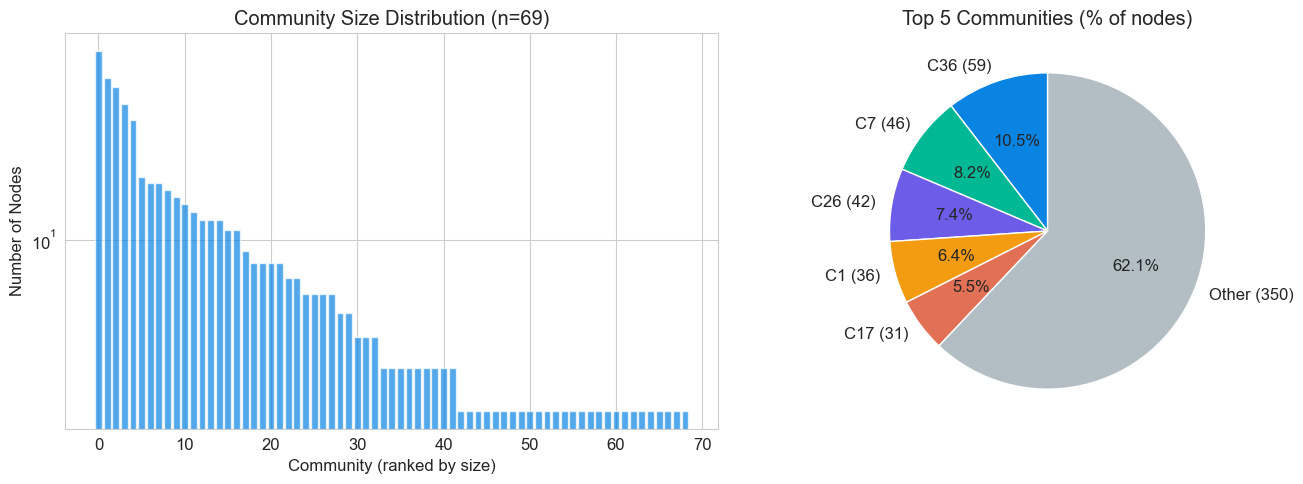

In [7]:
# Community size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size distribution
ax = axes[0]
sizes = sorted(community_sizes.values(), reverse=True)
ax.bar(range(len(sizes)), sizes, color='#0984e3', alpha=0.7, edgecolor='white')
ax.set_xlabel('Community (ranked by size)')
ax.set_ylabel('Number of Nodes')
ax.set_title(f'Community Size Distribution (n={n_communities})')
ax.set_yscale('log')

# Top 5 communities — pie chart of network coverage
ax = axes[1]
top5_sizes = [s for _, s in sorted_communities[:5]]
other_size = sum([s for _, s in sorted_communities[5:]])
labels = [f"C{sorted_communities[i][0]} ({top5_sizes[i]})" for i in range(5)] + [f"Other ({other_size})"]
values = top5_sizes + [other_size]
colors = ['#0984e3', '#00b894', '#6c5ce7', '#f39c12', '#e17055', '#b2bec3']
ax.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Top 5 Communities (% of nodes)')

plt.tight_layout()
plt.savefig('../figures/community_structure.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Network Evolution (2023–2026)

How has the procurement network changed over time?
- We slice the data by year (or quarter) and rebuild the network at each time step.
- Track: N(t), L(t), density, avg degree, top companies' positions.

In [8]:
# Create time slices (by year)
data['year'] = data['dataCelebracaoContrato'].dt.year

# Filter valid years
valid_years = sorted(data['year'].dropna().unique())
valid_years = [y for y in valid_years if 2023 <= y <= 2026]
print(f"Time periods: {valid_years}")
print(f"Contracts per year:")
print(data[data['year'].isin(valid_years)].groupby('year')['idcontrato'].count())

Time periods: [np.int32(2025), np.int32(2026)]
Contracts per year:
year
2025    670
2026     20
Name: idcontrato, dtype: int64


In [9]:
# Build network for each time period and track evolution
evolution_metrics = []

for year in valid_years:
    year_data = data[data['year'] == year]

    if len(year_data) < 10:
        continue

    G_year = build_network(year_data)
    G_year_und = G_year.to_undirected()

    # Metrics
    n_nodes = G_year.number_of_nodes()
    n_edges = G_year.number_of_edges()
    density = nx.density(G_year)
    avg_in_degree = np.mean([d for _, d in G_year.in_degree()]) if n_nodes > 0 else 0
    avg_strength = np.mean([d for _, d in G_year.in_degree(weight='weight')]) if n_nodes > 0 else 0

    # Clustering
    clustering = nx.average_clustering(G_year_und) if n_nodes > 2 else 0

    # Top company by in-degree
    if n_edges > 0:
        top_company = max(G_year.nodes(), key=lambda n: G_year.in_degree(n))
        top_degree = G_year.in_degree(top_company)
    else:
        top_company = "N/A"
        top_degree = 0

    evolution_metrics.append({
        'Year': int(year),
        'N': n_nodes,
        'L': n_edges,
        'Density': density,
        'Avg_Degree': avg_in_degree,
        'Avg_Strength': avg_strength,
        'Clustering': clustering,
        'Top_Company': top_company,
        'Top_Degree': top_degree,
        'Contracts': len(year_data)
    })

evolution_df = pd.DataFrame(evolution_metrics)
print("\nNetwork Evolution Metrics:")
print(evolution_df[['Year', 'N', 'L', 'Density', 'Avg_Degree', 'Clustering', 'Contracts']].to_string(index=False))


Network Evolution Metrics:
 Year   N   L  Density  Avg_Degree  Clustering  Contracts
 2025 554 554 0.001808    1.000000         0.0        670
 2026  24  16 0.028986    0.666667         0.0         20


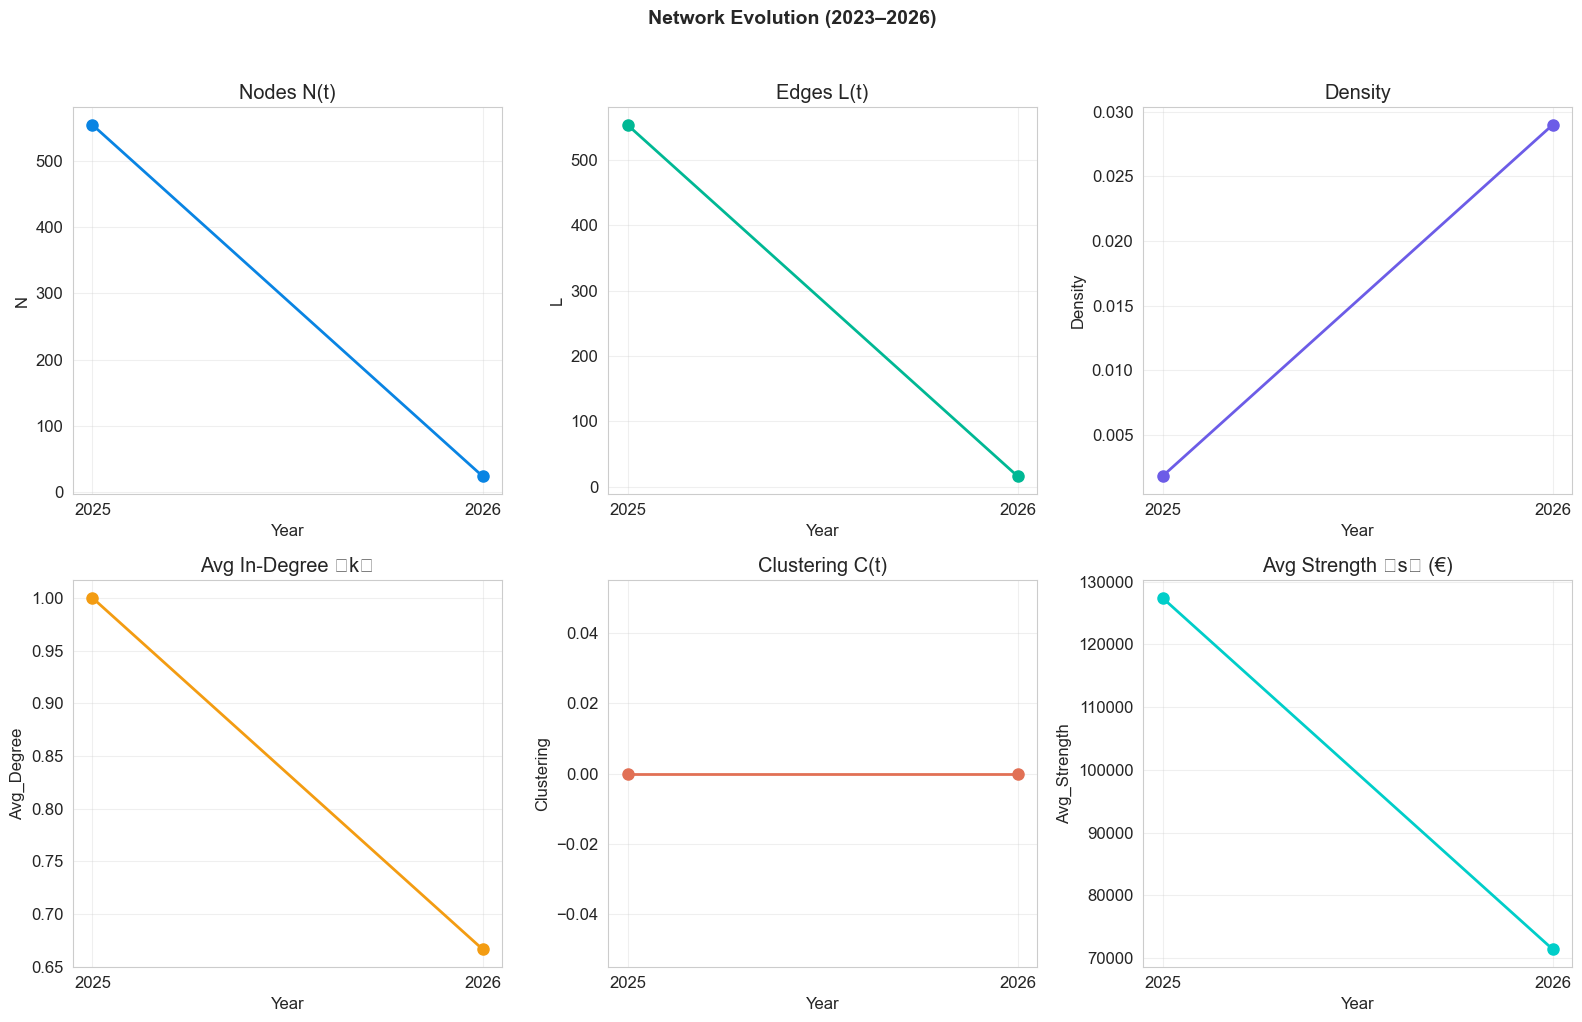

In [10]:
# Plot temporal evolution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics_to_plot = [
    ('N', 'Nodes N(t)', '#0984e3'),
    ('L', 'Edges L(t)', '#00b894'),
    ('Density', 'Density', '#6c5ce7'),
    ('Avg_Degree', 'Avg In-Degree ⟨k⟩', '#f39c12'),
    ('Clustering', 'Clustering C(t)', '#e17055'),
    ('Avg_Strength', 'Avg Strength ⟨s⟩ (€)', '#00cec9')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    ax = axes[idx // 3][idx % 3]
    ax.plot(evolution_df['Year'], evolution_df[metric], 'o-', color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(valid_years)

plt.suptitle('Network Evolution (2023–2026)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/network_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Track dominance stability over time: do the same companies stay on top?
print("="*60)
print("DOMINANCE STABILITY OVER TIME")
print("="*60)

top5_per_year = {}
for year in valid_years:
    year_data = data[data['year'] == year]
    if len(year_data) < 10:
        continue

    G_year = build_network(year_data)
    company_nodes = [n for n, attr in G_year.nodes(data=True) if attr.get('node_type') in ['adjudicatario', 'both']]

    # Top 5 by in-degree
    top5 = sorted(
        [(node, G_year.in_degree(node)) for node in company_nodes],
        key=lambda x: x[1], reverse=True
    )[:5]
    top5_per_year[year] = [x[0] for x in top5]

    print(f"\n{int(year)} — Top 5 by In-Degree:")
    for rank, (company, degree) in enumerate(top5, 1):
        print(f"  {rank}. {company[:40]} (k={degree})")

# Persistence analysis
if len(top5_per_year) >= 2:
    years = sorted(top5_per_year.keys())
    all_tops = set()
    for companies in top5_per_year.values():
        all_tops.update(companies)

    # Companies appearing in top 5 across ALL years
    persistent = set(top5_per_year[years[0]])
    for year in years[1:]:
        persistent &= set(top5_per_year[year])

    print(f"\n{'='*60}")
    print(f"Companies in Top 5 across ALL years: {len(persistent)}")
    for c in persistent:
        print(f"  → {c}")
    print(f"Total unique companies in Top 5 (any year): {len(all_tops)}")
    print(f"Persistence rate: {len(persistent)/5*100:.0f}%")

DOMINANCE STABILITY OVER TIME

2025 — Top 5 by In-Degree:
  1. claranet ii solutions (k=13)
  2. exitus solucoes tecnologicas (k=7)
  3. ohmtecnica representacoes de marcas (k=6)
  4. papelprint (k=5)
  5. timestamp sistemas de informacao (k=5)

2026 — Top 5 by In-Degree:
  1. wpp media (k=1)
  2. lucstockfood venda e distribuicao alimen (k=1)
  3. j vilaseca (k=1)
  4. abrancongelados produtos alimentares (k=1)
  5. saborfrio (k=1)

Companies in Top 5 across ALL years: 0
Total unique companies in Top 5 (any year): 10
Persistence rate: 0%


## 4. Lisbon Municipality — Focused Analysis

As the largest municipality, Lisbon deserves dedicated analysis.

In [12]:
# Filter data for Lisbon specifically
# Check available city names
print("Available municipalities (sample):")
print(data['city'].value_counts().head(20))

Available municipalities (sample):
city
Lisboa                    503
Sintra                     48
Oeiras                     37
Loures                     24
Cascais                    22
Mafra                      11
Alenquer                    5
Amadora                     5
Torres Vedras               4
Odivelas                    4
Cadaval                     4
Vila Franca de Xira         4
Lourinhã                    4
Sobral de Monte Agraço      2
Name: count, dtype: int64


In [13]:
# Build Lisbon subnetwork (adjust city name based on output above)
# Common names: 'lisboa', 'Lisboa', 'LISBOA' — check your data
lisbon_names = data['city'].value_counts().index
lisbon_candidates = [c for c in lisbon_names if 'lisb' in str(c).lower()]
print(f"Lisbon name variants found: {lisbon_candidates}")

if lisbon_candidates:
    lisbon_name = lisbon_candidates[0]  # Use the most common variant
    lisbon_data = data[data['city'] == lisbon_name]
else:
    # Fallback: use the most common city
    lisbon_name = data['city'].value_counts().index[0]
    lisbon_data = data[data['city'] == lisbon_name]
    print(f"WARNING: 'Lisboa' not found. Using most common city: {lisbon_name}")

print(f"\nLisbon contracts: {len(lisbon_data):,}")
print(f"Unique companies: {lisbon_data['adjudicatarios_clean'].nunique():,}")
print(f"Unique authorities: {lisbon_data['adjudicante_clean'].nunique():,}")

# Build Lisbon network
G_lisbon = build_network(lisbon_data)
print(f"\nLisbon Network:")
print(f"  Nodes: {G_lisbon.number_of_nodes():,}")
print(f"  Edges: {G_lisbon.number_of_edges():,}")
print(f"  Density: {nx.density(G_lisbon):.6f}")

Lisbon name variants found: ['Lisboa']

Lisbon contracts: 503
Unique companies: 313
Unique authorities: 98

Lisbon Network:
  Nodes: 411
  Edges: 399
  Density: 0.002368


In [14]:
# Top companies in Lisbon
lisbon_companies = [n for n, attr in G_lisbon.nodes(data=True) if attr.get('node_type') in ['adjudicatario', 'both']]

# By in-degree
lisbon_top_degree = sorted(
    [(n, G_lisbon.in_degree(n)) for n in lisbon_companies],
    key=lambda x: x[1], reverse=True
)[:10]

# By volume
lisbon_top_volume = sorted(
    [(n, G_lisbon.in_degree(n, weight='weight')) for n in lisbon_companies],
    key=lambda x: x[1], reverse=True
)[:10]

print("="*60)
print(f"LISBON ({lisbon_name}) — TOP COMPANIES")
print("="*60)

print("\nBy Number of Authorities (In-Degree):")
for rank, (company, deg) in enumerate(lisbon_top_degree, 1):
    print(f"  {rank}. {company[:45]} — {deg} authorities")

print("\nBy Contract Volume (€):")
for rank, (company, vol) in enumerate(lisbon_top_volume, 1):
    print(f"  {rank}. {company[:45]} — €{vol:,.0f}")

# Market share of top company in Lisbon
total_lisbon_value = lisbon_data['precoContratual'].sum()
top_lisbon_share = lisbon_top_volume[0][1] / total_lisbon_value * 100
print(f"\nTop company market share in Lisbon: {top_lisbon_share:.1f}%")

LISBON (Lisboa) — TOP COMPANIES

By Number of Authorities (In-Degree):
  1. claranet ii solutions — 13 authorities
  2. exitus solucoes tecnologicas — 6 authorities
  3. inetum espana sucursal em portugal — 6 authorities
  4. papelprint — 5 authorities
  5. timestamp sistemas de informacao — 5 authorities
  6. base2 — 4 authorities
  7. ohmtecnica representacoes de marcas — 4 authorities
  8. planeta vertical — 4 authorities
  9. basedois informatica e telecomunicacoes — 3 authorities
  10. digiberia information technologies — 3 authorities

By Contract Volume (€):
  1. paldata — €2,999,800
  2. inetum espana sucursal em portugal — €2,734,017
  3. claranet ii solutions — €2,356,474
  4. nos comunicacoes — €2,210,995
  5. warpcom services — €2,201,029
  6. meo servicos de comunicacoes e multimedia — €2,191,600
  7. hccm consulting — €1,566,521
  8. vodafone portugal comunicacoes pessoais — €1,172,188
  9. fujitsu technology solutions — €1,107,248
  10. reload consultoria informatica — €

## 5. Key Insights — The 4 Golden Questions

### Framework for the presentation discussion

In [15]:
# Summary of key findings for the presentation
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    THE 4 GOLDEN QUESTIONS                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. WHAT WAS YOUR EXPECTATION?                                       ║
║     ─────────────────────────────                                    ║
║     We expected:                                                     ║
║     • A few large companies dominating the market (heavy tail)       ║
║     • Geographic specialization (local companies per municipality)   ║
║     • Clear community structure reflecting geography or sector       ║
║     • Increasing concentration over time                             ║
║                                                                      ║
║  2. WHAT IS THE PROPER RANDOM REFERENCE?                             ║
║     ─────────────────────────────────────                            ║
║     • Erdős-Rényi (ER) random graph with same N and ⟨k⟩             ║
║     • Under ER: Poisson degree distribution, low clustering,        ║
║       no community structure, uniform hub probability                ║
║                                                                      ║
║  3. HOW DO THE RESULTS COMPARE TO YOUR EXPECTATIONS?                 ║
║     ────────────────────────────────────────────────                 ║
║     [Fill after running the analysis]                                ║
║     • Degree distribution: power-law vs Poisson? alpha = ?           ║
║     • Clustering: real C vs ER C → ratio?                            ║
║     • Modularity: real Q vs random Q → community strength?           ║
║     • Dominance: is there really a heavy tail / concentration?       ║
║                                                                      ║
║  4. WHAT DID YOU LEARN FROM EACH QUANTITY?                           ║
║     ──────────────────────────────────────                           ║
║     • N, L → scale of the procurement market                        ║
║     • Degree dist → market structure (concentrated vs competitive)   ║
║     • Clustering → local alliances / geographic proximity            ║
║     • Path length → market accessibility / distance between actors   ║
║     • Communities → natural market segments                          ║
║     • HHI → municipal concentration levels                          ║
║     • Time evolution → market becoming more/less competitive         ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                    THE 4 GOLDEN QUESTIONS                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. WHAT WAS YOUR EXPECTATION?                                       ║
║     ─────────────────────────────                                    ║
║     We expected:                                                     ║
║     • A few large companies dominating the market (heavy tail)       ║
║     • Geographic specialization (local companies per municipality)   ║
║     • Clear community structure reflecting geography or sector       ║
║     • Increasing concentration over time                             ║
║                                                                      ║
║  2. WHAT IS THE PROPER RANDOM REFERENCE?                             ║
║     ─────────────────────────────────────        

In [16]:
# Final export
print("="*60)
print("FIGURES GENERATED (for presentation):")
print("="*60)
print("""
../figures/community_structure.png    — Community size distribution + pie chart
../figures/network_evolution.png      — N(t), L(t), density, degree, clustering over time

From Notebook 04:
../figures/distributions.png          — P(k) and P(s) log-log
../figures/top10_national.png         — Top 10 by degree vs volume
../figures/geographic_dispersion.png  — Geographic reach
../figures/cpv_heatmap.png            — Sector specialization heatmap
../figures/hhi_concentration.png      — HHI per municipality
../figures/degree_vs_random.png       — Real vs ER comparison
""")

print("\n✅ Notebook 05 complete!")
print("\nNext steps:")
print("1. Run both notebooks 04 and 05")
print("2. Fill in the [placeholder] fields in the presentation with results")
print("3. Copy generated figures to presentation slides")
print("4. Write the 4 Golden Questions answers based on your actual results")

FIGURES GENERATED (for presentation):

../figures/community_structure.png    — Community size distribution + pie chart
../figures/network_evolution.png      — N(t), L(t), density, degree, clustering over time

From Notebook 04:
../figures/distributions.png          — P(k) and P(s) log-log
../figures/top10_national.png         — Top 10 by degree vs volume
../figures/geographic_dispersion.png  — Geographic reach
../figures/cpv_heatmap.png            — Sector specialization heatmap
../figures/hhi_concentration.png      — HHI per municipality
../figures/degree_vs_random.png       — Real vs ER comparison


✅ Notebook 05 complete!

Next steps:
1. Run both notebooks 04 and 05
2. Fill in the [placeholder] fields in the presentation with results
3. Copy generated figures to presentation slides
4. Write the 4 Golden Questions answers based on your actual results
